In [ ]:
%matplotlib inline
import os

# feiura
try:
    ORIGINAL
except NameError:
    ORIGINAL = os.getcwd()
    if ORIGINAL.strip("/").endswith("scenarios/main"):
        os.chdir("../../")

from easyvvuq.analysis.sc_analysis import SCAnalysisResults

from typing import cast

from src import machines
from src import programs
from src import energyuq
from src.util import plot, parser
from src.util.data import *


import matplotlib.pyplot as plt
import numpy as np

/home/machado/energyuq/.venv/lib/python3.14/site-packages/chaospy/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/home/machado/energyuq/.venv/lib/python3.14/site-packages/cerberus/validator.py:618: UserWarning: These types are defined both with a method and in the'types_mapping' property of this validator: {'integer'}
  warn(


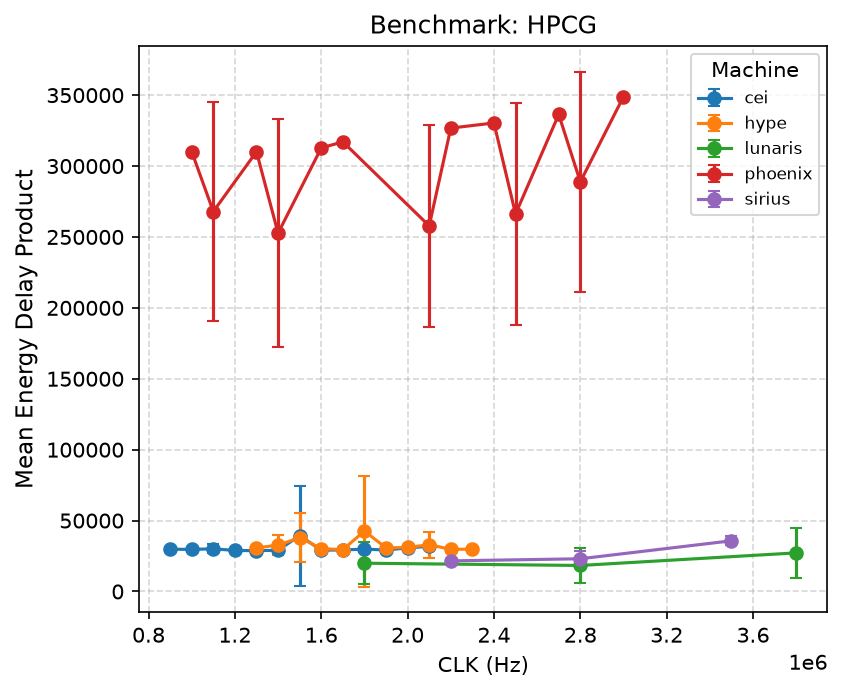

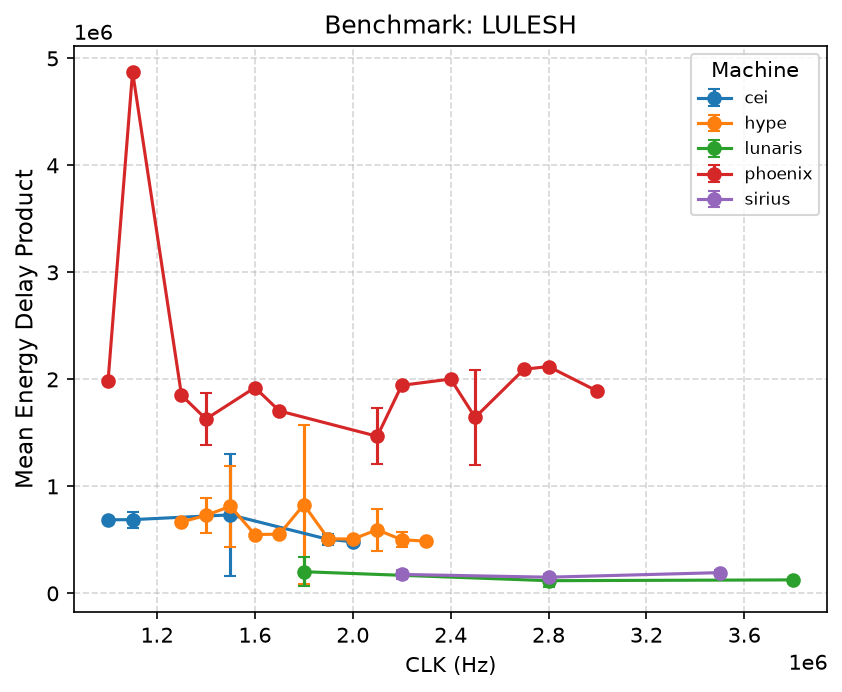

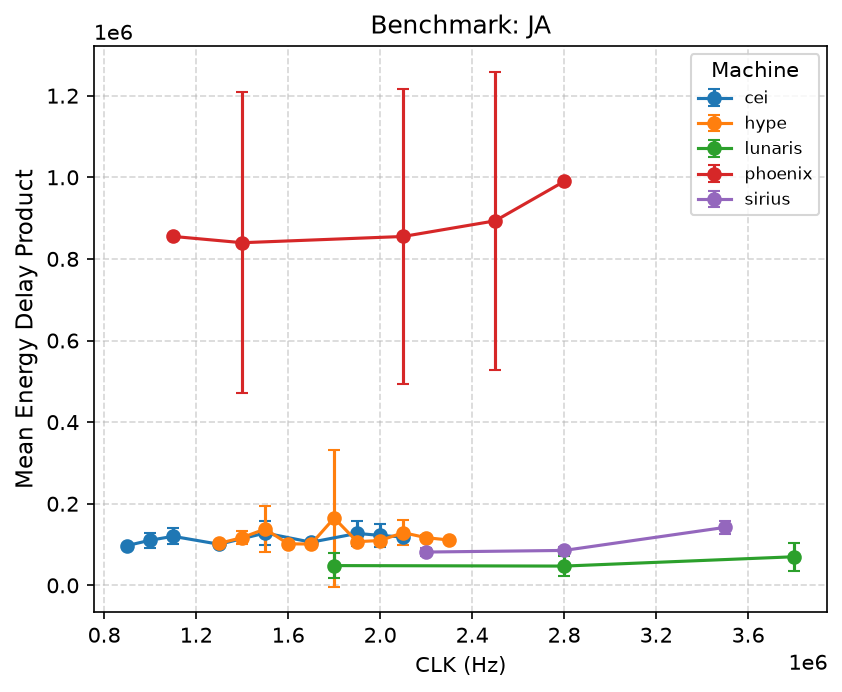

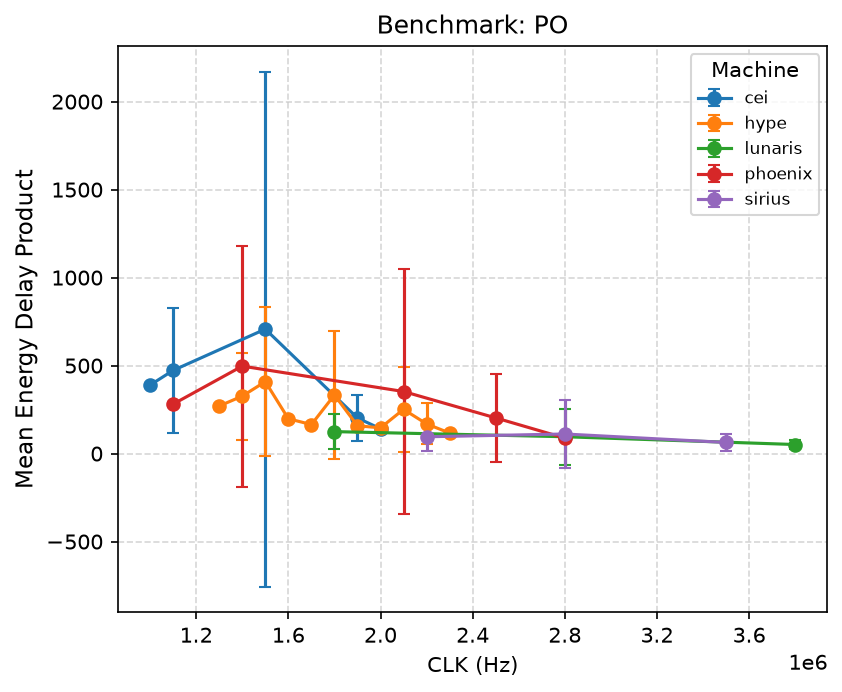

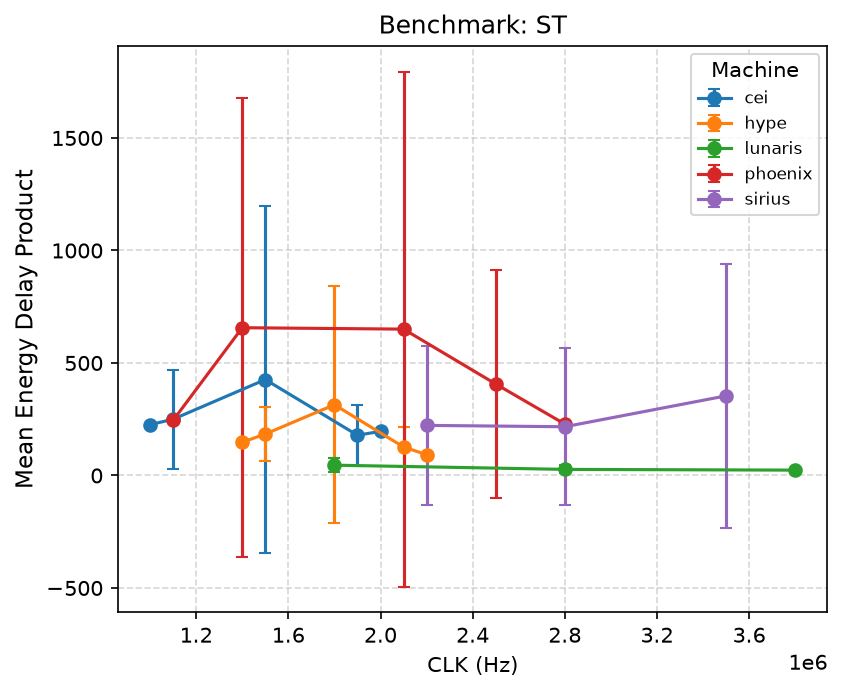

In [ ]:
from src.util.multi_plot import plot_multi_best_configurations, plot_multi_sobols, plot_multi_energy_time_pareto, plot_multi_parameter_effects
from src.util.multi_run import discover_runs
from pathlib import Path

Path("out").mkdir(exist_ok=True)

def energy_delay_product(df):
    return (df["energy_uj"] * 1e-6) * df["time"]

for bench in ("HPCG", "LULESH", "JA", "PO", "ST"):
    runs = discover_runs(benchmark_filter=[bench])
    # f = plot_multi_best_configurations(runs)
    # f.set_dpi(150)
    # f.savefig(f"out/plot_multi_best_configurations_{bench}")
    # g = plot_multi_sobols(runs, mode="stacked_bar")
    # g.set_dpi(150)
    # g.savefig(f"out/plot_multi_sobols_{bench}")
    # h = plot_multi_energy_time_pareto(runs)
    # h.set_dpi(150)
    # h.savefig(f"out/plot_multi_energy_time_pareto_{bench}")
    i = plot_multi_parameter_effects(runs, param="CLK", qoi=energy_delay_product)
    i.set_dpi(150)
    i.savefig(f"out/plot_multi_energy_time_pareto_{bench}")

In [ ]:
from scripts.compile_plots_html import compile_plots_html

compile_plots_html("runs", quiet=True, output_path="reports/index.html")

In [ ]:
# from src.util import compile_plots_pdf
# compile_plots_pdf(
#     runs="runs/NTHREADS_CLK",
#     output_path="reports/energyuq_master_report.pdf",
#     benchmarks=["HPCG", "PO"],
#     dpi=150,
# )

In [ ]:
# from src.util import RunCollection
# runs = RunCollection.discover("runs/NTHREADS_CLK")
# # Run individual analyses in bulk for all runs
# reports = runs.analyze_each(output_dir="individual_analyses", qois=["energy_uj", "time"])
# # Access metrics and figures for a specific run
# hpcg_cei_report = reports["HPCG_cei"]
# print("HPCG on CEI metrics:", hpcg_cei_report["metrics"]["qois"]["energy_uj"]["sample_statistics"])